# Consolidated Homing/Escape Detection Pipeline

Clean, streamlined workflow for Phase 1-3 homing detection analysis.

In [5]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

from behave_analysis.analyze.analyze_homing_consolidated import HomingAnalyzer

%matplotlib inline

In [2]:
# Import experiments
from behave_analysis.database.Experiments.JAL004_ex import (
    JAL4_flip4_3Sept, JAL4_flip6_19Sept, JAL4_flip3_28aug, JAL4_flip5_11Sept
)
from behave_analysis.database.Experiments.JAL005_ex import JAL5_flip1_8Sept, JAL5_flip3_21Sept
from behave_analysis.database.Experiments.JAL006_ex import (
    JAL6_flip6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar
)
from behave_analysis.database.Experiments.JAL007_ex import (
    JAL7_flip8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_flip9_16apr, JAL7_flip10_23apr
)
from behave_analysis.database.Experiments.JAL008_ex import (
    JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip5_14may, JAL8_flip4_10may
)

experiments_objects = {
    "JAL4_3rdSept": JAL4_flip4_3Sept,
    "JAL4_19thSept": JAL4_flip6_19Sept,
    "JAL4_28aug": JAL4_flip3_28aug,
    "JAL4_11thSept": JAL4_flip5_11Sept,
    "JAL5_8thSept": JAL5_flip1_8Sept,
    "JAL5_21stSept": JAL5_flip3_21Sept,
    "JAL6_28mar": JAL6_flip6_28mar,
    "JAL6_flip4_21mar": JAL6_flip4_21mar,
    "JAL6_flip3_18mar": JAL6_flip3_18mar,
    "JAL6_flip5_25mar": JAL6_flip5_25mar,
    "JAL7_sesh8_9apr": JAL7_flip8_9apr,
    "JAL7_flip5_22mar": JAL7_flip5_22mar,
    "JAL7_flip2_12mar": JAL7_flip2_12mar,
    "JAL7_sesh9_16apr": JAL7_flip9_16apr,
    "JAL7_23apr": JAL7_flip10_23apr,
    "JAL8_flip1_25apr": JAL8_flip1_25apr,
    "JAL8_flip2_29apr": JAL8_flip2_29apr,
    "JAL8_flip3_7may": JAL8_flip3_7may,
    "JAL8_14may": JAL8_flip5_14may,
    "JAL8_flip4_10may": JAL8_flip4_10may,
}

print(f"✓ Loaded {len(experiments_objects)} experiments")

✓ Loaded 20 experiments


In [6]:
# Initialize and load data

analyzer = HomingAnalyzer(experiments_objects)
analyzer.load_all_sessions()
print(f"✓ Loaded {len(analyzer.session_data)} sessions")

2026-06-17 14:48:13.776 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:load_all_sessions:92 - Loading 20 sessions...
2026-06-17 14:48:13.887 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-06-17 14:48:42.860 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:load_all_sessions:121 -   ✓ JAL4_3rdSept
2026-06-17 14:48:43.010 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-06-17 14:49:13.791 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:load_all_sessions:121 -   ✓ JAL4_19thSept
2026-06-17 14:49:13.932 | INFO     | behave_analysis.process.process:load_session:117 - All data has been moved from winstor to ceph so we always load ceph data now
2026-06-17 14:49:40.784 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:load_all_sessions:12

✓ Loaded 20 sessions


In [19]:
# Phase 1: Extract runs and manual events
speed_threshold = 4
speed_gap_tolerance = 1
analyzer.extract_runs(speed_threshold=speed_threshold, gap_tolerance_frames=speed_gap_tolerance)
analyzer.extract_manual_runs()
analyzer.label_extracted_runs(overlap_threshold=0.5)

print(f"✓ Extracted {len(analyzer.extracted_runs)} runs")
print(f"✓ Extracted {len(analyzer.manual_runs)} manually-labelled events")

n_exploration = sum(1 for r in analyzer.extracted_runs if r.is_exploration)
print(f"  - {n_exploration} exploration runs")
print(f"  - {len(analyzer.extracted_runs) - n_exploration} target-overlapping runs")

2026-06-17 20:12:45.971 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:extract_runs:130 - Extracting runs (threshold=4 cm/s, gap_tolerance=1 frames)...
2026-06-17 20:12:46.987 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:extract_runs:169 -   ✓ Extracted 92503 runs across 20 sessions
2026-06-17 20:12:46.995 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:extract_manual_runs:173 - Extracting manually-labelled homing/escape runs...
2026-06-17 20:12:47.281 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:extract_manual_runs:204 -   ✓ Extracted 1908 manually-labelled runs
2026-06-17 20:12:47.282 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:label_extracted_runs:232 - Labeling extracted runs (overlap_threshold=0.5)...
2026-06-17 20:13:19.221 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:label_extracted_runs:250 -   ✓ 89902 extracted runs labeled as exploration


✓ Extracted 92503 runs
✓ Extracted 1908 manually-labelled events
  - 89902 exploration runs
  - 2601 target-overlapping runs


In [23]:
# Extract features for all runs
analyzer.extract_features()
print(f"✓ Extracted features for {len(analyzer.all_runs)} runs")

2026-06-17 20:20:58.851 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:extract_features:257 - Extracting features for all runs...
2026-06-17 20:21:11.692 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:extract_features:271 -   ✓ Extracted features for 94411 runs


✓ Extracted features for 94411 runs


2026-06-17 20:21:14.397 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:compute_feature_distributions:349 - Computing feature distributions (exploration vs manually-labelled)...
2026-06-17 20:21:17.896 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:compute_feature_distributions:426 -   Feature ranking (by |Cohen's d|):
2026-06-17 20:21:17.896 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:compute_feature_distributions:428 -     1. net_distance: d=3.146, AUC=0.970, p=0.000e+00
2026-06-17 20:21:17.896 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:compute_feature_distributions:428 -     2. net_dy: d=3.118, AUC=0.991, p=0.000e+00
2026-06-17 20:21:17.904 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:compute_feature_distributions:428 -     3. speed_peak: d=2.278, AUC=0.975, p=0.000e+00
2026-06-17 20:21:17.904 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:compute_feature_distributions

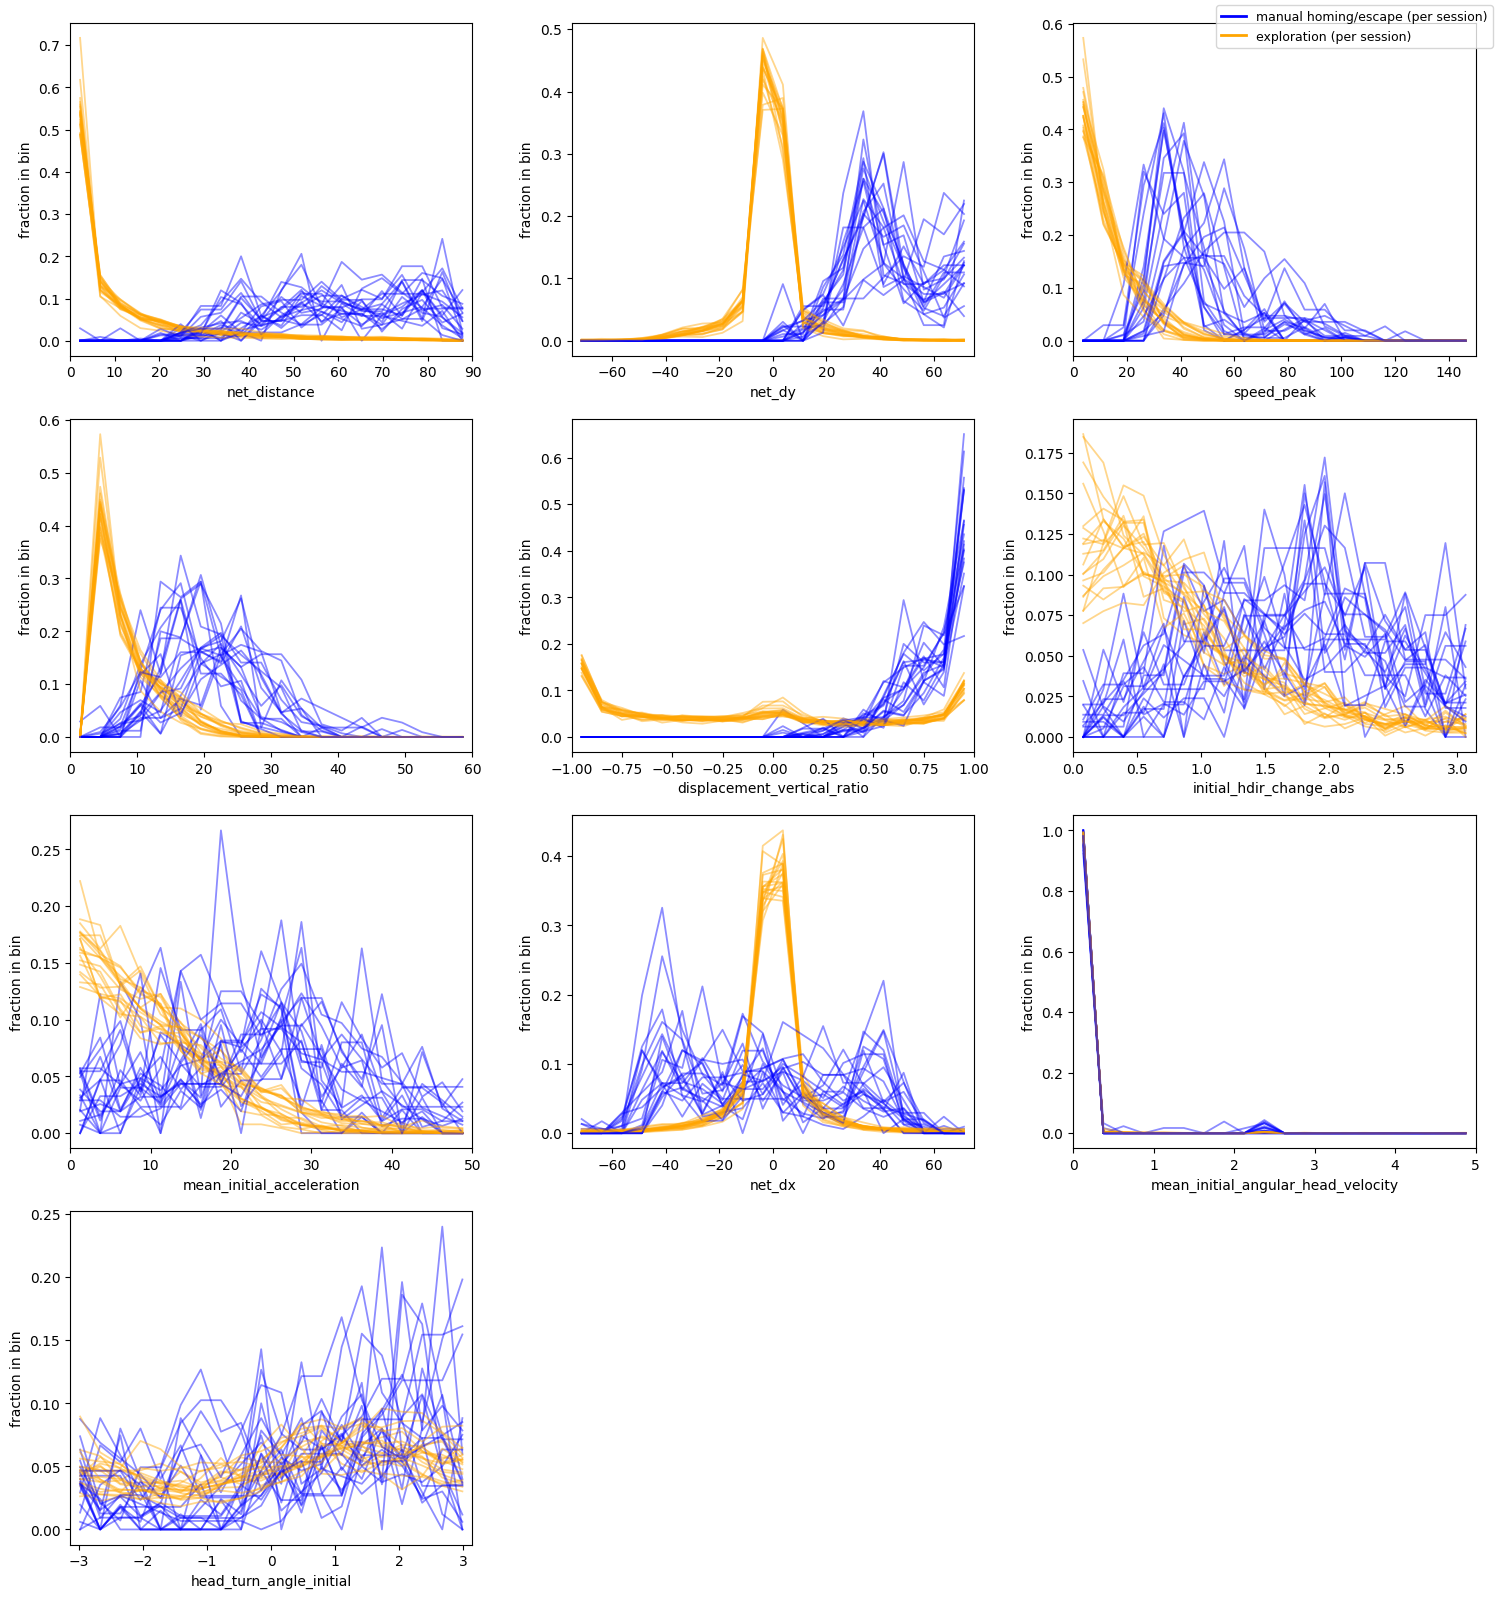


✓ Top 10 discriminative features:
  1. net_distance: d=3.146, AUC_pooled=0.970, AUC_session_mean=0.969 (n_sessions=20)
  2. net_dy: d=3.118, AUC_pooled=0.991, AUC_session_mean=0.990 (n_sessions=20)
  3. speed_peak: d=2.278, AUC_pooled=0.975, AUC_session_mean=0.980 (n_sessions=20)
  4. speed_mean: d=1.991, AUC_pooled=0.932, AUC_session_mean=0.929 (n_sessions=20)
  5. displacement_vertical_ratio: d=1.868, AUC_pooled=0.876, AUC_session_mean=0.876 (n_sessions=20)
  6. initial_hdir_change_abs: d=1.220, AUC_pooled=0.810, AUC_session_mean=0.813 (n_sessions=20)
  7. mean_initial_acceleration: d=0.915, AUC_pooled=0.785, AUC_session_mean=0.777 (n_sessions=20)
  8. net_dx: d=-0.248, AUC_pooled=0.424, AUC_session_mean=0.438 (n_sessions=20)
  9. mean_initial_angular_head_velocity: d=0.210, AUC_pooled=0.664, AUC_session_mean=0.676 (n_sessions=20)
  10. head_turn_angle_initial: d=0.192, AUC_pooled=0.555, AUC_session_mean=0.564 (n_sessions=20)


In [24]:
# Compute and plot feature distributions (exploration vs manual target)
discrimination_results = analyzer.compute_feature_distributions()
analyzer.plot_feature_distributions(only_top_n=10)
plt.show()

print("\n✓ Top 10 discriminative features:")
for idx, (fname, stats_dict) in enumerate(analyzer.feature_ranking[:10]):
    print(
        f"  {idx+1}. {fname}: d={stats_dict['cohens_d']:.3f}, "
        f"AUC_pooled={stats_dict['auc']:.3f}, "
        f"AUC_session_mean={stats_dict['auc_session_mean']:.3f} "
        f"(n_sessions={stats_dict['auc_session_n']})"
    )

In [25]:
# Phase 2: Fit gates from manual distributions OR use manual thresholds
# Option A: Learn gates from manually-labelled data (default)
gates = analyzer.fit_phase2_gates(target_recall=0.90)

print(f"\n✓ Fitted {len(gates)} feature gates")
for fname, gate in gates.items():
    print(f"  {fname}: {gate['dir']} {gate['threshold']:.4f} (recall={gate['recall']:.3f}, precision={gate['precision']:.3f})")

2026-06-17 20:23:35.278 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:fit_phase2_gates:537 - Fitting Phase 2 gates (target_recall=0.9)...
2026-06-17 20:23:35.366 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:fit_phase2_gates:586 -   net_distance: keep if value >= 36.4551 (recall=0.910, precision=0.203)
2026-06-17 20:23:35.452 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:fit_phase2_gates:586 -   net_dy: keep if value >= 23.7879 (recall=0.926, precision=0.435)
2026-06-17 20:23:35.546 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:fit_phase2_gates:586 -   speed_peak: keep if value >= 30.5942 (recall=0.911, precision=0.225)
2026-06-17 20:23:35.628 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:fit_phase2_gates:586 -   speed_mean: keep if value >= 12.1877 (recall=0.905, precision=0.089)



✓ Fitted 4 feature gates
  net_distance: >= 36.4551 (recall=0.910, precision=0.203)
  net_dy: >= 23.7879 (recall=0.926, precision=0.435)
  speed_peak: >= 30.5942 (recall=0.911, precision=0.225)
  speed_mean: >= 12.1877 (recall=0.905, precision=0.089)


In [31]:
# Run Phase 2 classification
candidates = analyzer.run_phase2_classification(use_learned_gates=True)

print(f"\n✓ Phase 2 classification complete")
print(f"Total candidates: {len(candidates)}")

# Count per session
for session_name, cands in analyzer.phase2_candidates_by_session.items():
    print(f"  {session_name}: {len(cands)} candidates")

2026-06-18 07:31:02.314 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:run_phase2_classification:614 - Running Phase 2 classification with 4 gates...
2026-06-18 07:31:02.598 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:run_phase2_classification:650 -   ✓ 2468 runs passed Phase 2 gates



✓ Phase 2 classification complete
Total candidates: 2468
  JAL4_3rdSept: 76 candidates
  JAL4_19thSept: 93 candidates
  JAL4_28aug: 47 candidates
  JAL4_11thSept: 31 candidates
  JAL5_8thSept: 70 candidates
  JAL5_21stSept: 36 candidates
  JAL6_28mar: 211 candidates
  JAL6_flip4_21mar: 177 candidates
  JAL6_flip3_18mar: 195 candidates
  JAL6_flip5_25mar: 143 candidates
  JAL7_sesh8_9apr: 146 candidates
  JAL7_flip5_22mar: 110 candidates
  JAL7_flip2_12mar: 108 candidates
  JAL7_sesh9_16apr: 105 candidates
  JAL7_23apr: 132 candidates
  JAL8_flip1_25apr: 120 candidates
  JAL8_flip2_29apr: 71 candidates
  JAL8_flip3_7may: 194 candidates
  JAL8_14may: 204 candidates
  JAL8_flip4_10may: 199 candidates


In [32]:
# Phase 3: Overlap metrics
phase3_results = analyzer.compute_phase3_overlap(
    candidates_by_session=analyzer.phase2_candidates_by_session
 )

print(f"\n✓ Phase 3 overlap analysis:")
for session_name, metrics in phase3_results['by_session'].items():
    print(f"\n  {session_name}:")
    print(f"    Extracted runs: {metrics['n_extracted']}")
    print(f"    Manual events: {metrics['n_manual']}")
    print(f"    Mean frac labelled: {metrics['mean_fraction_extracted_that_are_manually_labelled']:.3f}")
    print(f"    Mean frac extracted: {metrics['mean_fraction_manual_that_are_extracted']:.3f}")
    print(f"    Manual with >1 extracted: {metrics['fraction_manual_with_multiple_extracted']:.3f}")

2026-06-18 07:31:08.482 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:compute_phase3_overlap:686 - Computing Phase 3 overlap metrics...
2026-06-18 07:31:09.214 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:compute_phase3_overlap:760 -   ✓ Phase 3 overlap computed



✓ Phase 3 overlap analysis:

  JAL4_3rdSept:
    Extracted runs: 76
    Manual events: 75
    Mean frac labelled: 0.750
    Mean frac extracted: 0.612
    Manual with >1 extracted: 0.053

  JAL4_19thSept:
    Extracted runs: 93
    Manual events: 94
    Mean frac labelled: 0.712
    Mean frac extracted: 0.489
    Manual with >1 extracted: 0.011

  JAL4_28aug:
    Extracted runs: 47
    Manual events: 34
    Mean frac labelled: 0.398
    Mean frac extracted: 0.444
    Manual with >1 extracted: 0.029

  JAL4_11thSept:
    Extracted runs: 31
    Manual events: 50
    Mean frac labelled: 0.854
    Mean frac extracted: 0.393
    Manual with >1 extracted: 0.000

  JAL5_8thSept:
    Extracted runs: 70
    Manual events: 79
    Mean frac labelled: 0.641
    Mean frac extracted: 0.444
    Manual with >1 extracted: 0.025

  JAL5_21stSept:
    Extracted runs: 36
    Manual events: 58
    Mean frac labelled: 0.770
    Mean frac extracted: 0.404
    Manual with >1 extracted: 0.034

  JAL6_28mar:
 

In [ ]:
# 3,11,14,15,19
# Launch interactive Syd viewer with curation
# NOTE: You can inspect candidate and manual masks in all modes
# include_manual_events_in_iteration=True  -> iterate over candidates + manual
# include_manual_events_in_iteration=False -> iterate candidates only (still shows both masks)

viewer = analyzer.create_syd_viewer(
    candidates=candidates,
    session_name=None,  # None = all sessions; set to specific name to filter
    removed_run_log_path=analyzer.output_dir / 'removed_runs.csv',
    speed_threshold=speed_threshold,
    include_manual_events_in_iteration=False,
 )
viewer.show()

2026-06-18 07:33:00.918 | INFO     | behave_analysis.analyze.analyze_homing_consolidated:create_syd_viewer:976 - Syd viewer created. Set remove_current=1 on a candidate trial to mark removal.


In [ ]:
# Manual curation: specify removed event IDs (from viewer)
# Example: removed_event_ids = [0, 5, 12]  # Event IDs to remove
removed_event_ids = []  # UPDATE THIS with IDs marked for removal in the viewer

if removed_event_ids:
    analyzer.save_removed_runs(viewer, removed_event_ids)
    print(f"✓ Saved {len(removed_event_ids)} removed events")
else:
    print("No runs marked for removal")